# EDA

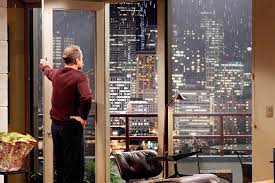

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

## Load the data

In [2]:
from pathlib import Path

data_dir = Path("data")
csv_path = next(data_dir.glob("*.csv"))

df = pd.read_csv(csv_path)
print(f"Loaded {csv_path.name}")
df.head()

Loaded _SELECT_kchd_kchs_date_kchs_price_FROM_eda_king_county_house_det_202609161451.csv


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,2014-10-13,221900.000
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,2014-12-09,538000.000
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,2015-02-25,180000.000
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,2014-12-09,604000.000
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,2015-02-18,510000.000


## Descriptive statistics

In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 21597, Columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21597.000,NaN,NaN,NaN,4580474287.771,2876735715.748,1000102.000,2123049175.000,3904930410.000,7308900490.000,9900000190.000
bedrooms,21597.000,NaN,NaN,NaN,3.373,0.926,1.000,3.000,3.000,4.000,33.000
bathrooms,21597.000,NaN,NaN,NaN,2.116,0.769,0.500,1.750,2.250,2.500,8.000
sqft_living,21597.000,NaN,NaN,NaN,2080.322,918.106,370.000,1430.000,1910.000,2550.000,13540.000
sqft_lot,21597.000,NaN,NaN,NaN,15099.409,41412.637,520.000,5040.000,7618.000,10685.000,1651359.000
floors,21597.000,NaN,NaN,NaN,1.494,0.540,1.000,1.000,1.500,2.000,3.500
waterfront,19206.000,NaN,NaN,NaN,0.008,0.087,0.000,0.000,0.000,0.000,1.000
view,21534.000,NaN,NaN,NaN,0.234,0.766,0.000,0.000,0.000,0.000,4.000
condition,21597.000,NaN,NaN,NaN,3.410,0.651,1.000,3.000,3.000,4.000,5.000
grade,21597.000,NaN,NaN,NaN,7.658,1.173,3.000,7.000,7.000,8.000,13.000


## Distributions

### Continuous variables

Numeric columns that can take a wide range of values (as opposed to a fixed set of categories).

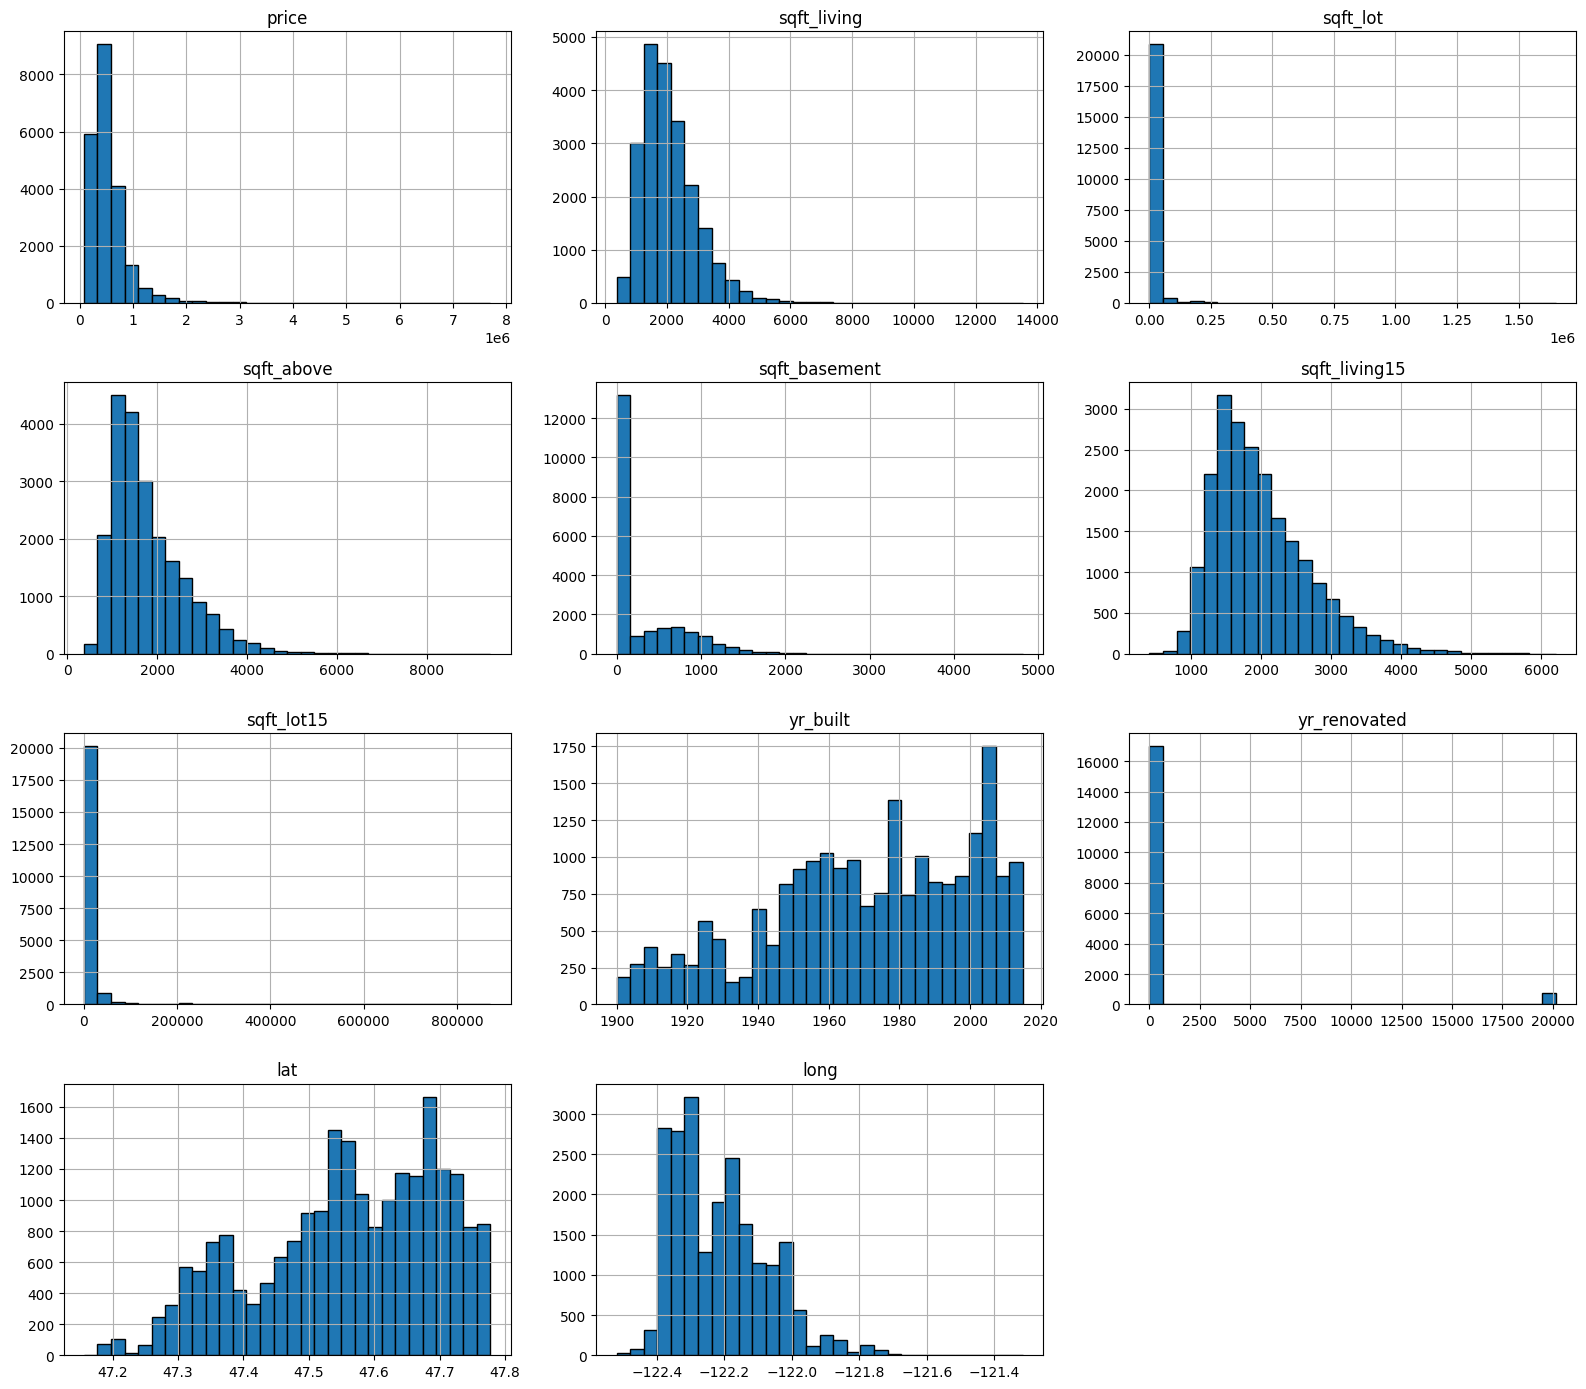

In [5]:
continuous_cols = [
    "price",
    "sqft_living",
    "sqft_lot",
    "sqft_above",
    "sqft_basement",
    "sqft_living15",
    "sqft_lot15",
    "yr_built",
    "yr_renovated",
    "lat",
    "long",
]

df[continuous_cols].hist(bins=30, figsize=(16, 14), edgecolor="black")
plt.tight_layout()
plt.show()

In [6]:
# Skewness: 0 = symmetric, >1 or <-1 = strongly skewed
# IQR outlier count: values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
skew_stats = df[continuous_cols].skew().rename("skewness")

q1 = df[continuous_cols].quantile(0.25)
q3 = df[continuous_cols].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_count = (
    (df[continuous_cols] < lower_bound) | (df[continuous_cols] > upper_bound)
).sum().rename("outliers_iqr")
outlier_pct = (outlier_count / len(df) * 100).rename("outliers_pct")

pd.concat([skew_stats, outlier_count, outlier_pct], axis=1).sort_values(
    "skewness", ascending=False
)

,skewness,outliers_iqr,outliers_pct
sqft_lot,13.073,2419,11.201
sqft_lot15,9.524,2188,10.131
yr_renovated,4.573,744,3.445
price,4.023,1158,5.362
sqft_basement,1.574,484,2.241
sqft_living,1.473,571,2.644
sqft_above,1.447,610,2.824
sqft_living15,1.107,543,2.514
long,0.885,255,1.181
yr_built,-0.469,0,0.000


### Categorical variables

Columns with a fixed, limited set of values.

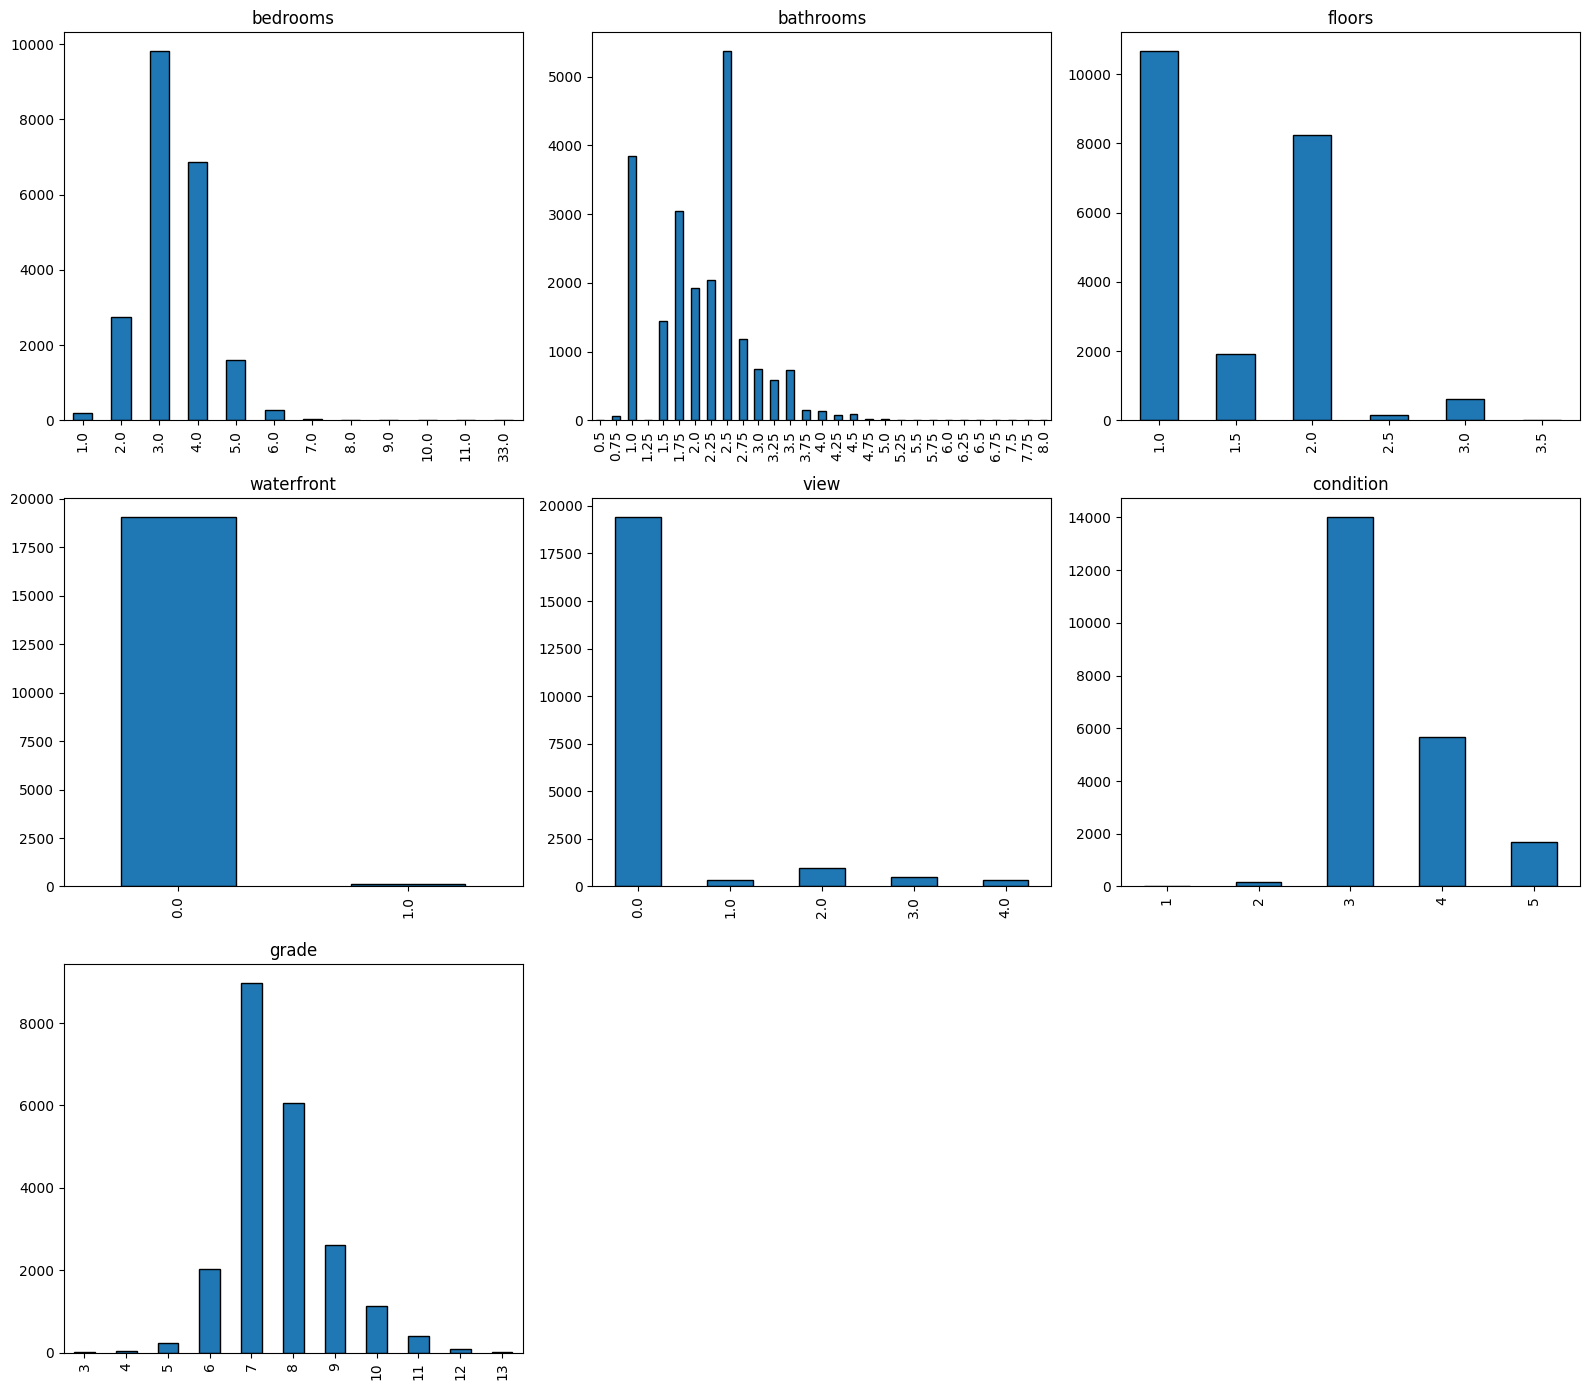

In [7]:
categorical_cols = ["bedrooms", "bathrooms", "floors", "waterfront", "view", "condition", "grade"]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax, edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes[len(categorical_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# exact counts + share of total behind each bar above
for col in categorical_cols:
    counts = df[col].value_counts().sort_index()
    share = (counts / len(df) * 100).round(1)
    print(pd.concat([counts.rename("count"), share.rename("pct")], axis=1))
    print()

          count    pct
bedrooms              
1.000       196  0.900
2.000      2760 12.800
3.000      9824 45.500
4.000      6882 31.900
5.000      1601  7.400
6.000       272  1.300
7.000        38  0.200
8.000        13  0.100
9.000         6  0.000
10.000        3  0.000
11.000        1  0.000
33.000        1  0.000

           count    pct
bathrooms              
0.500          4  0.000
0.750         71  0.300
1.000       3851 17.800
1.250          9  0.000
1.500       1445  6.700
1.750       3048 14.100
2.000       1930  8.900
2.250       2047  9.500
2.500       5377 24.900
2.750       1185  5.500
3.000        753  3.500
3.250        589  2.700
3.500        731  3.400
3.750        155  0.700
4.000        136  0.600
4.250         79  0.400
4.500        100  0.500
4.750         23  0.100
5.000         21  0.100
5.250         13  0.100
5.500         10  0.000
5.750          4  0.000
6.000          6  0.000
6.250          2  0.000
6.500          2  0.000
6.750          2  0.000
7.500

### zipcode — a high-cardinality categorical

Too many distinct values for a readable bar chart of all of them, so look at the top ones instead.

Unique zipcodes: 70
count    70.000
mean    308.529
std     142.224
min      50.000
25%     204.250
50%     282.500
75%     408.250
max     602.000
Name: count, dtype: float64


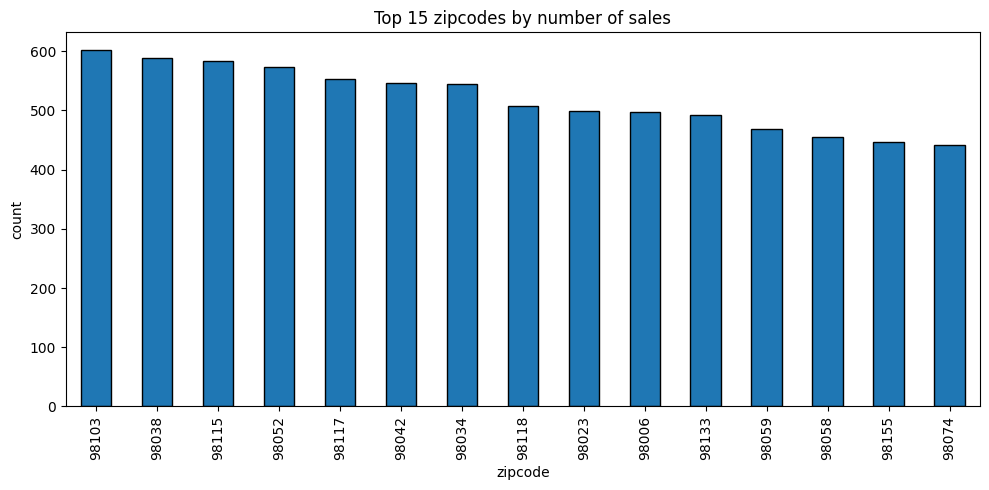

In [9]:
print(f"Unique zipcodes: {df['zipcode'].nunique()}")
print(df["zipcode"].value_counts().describe())

df["zipcode"].value_counts().head(15).plot(kind="bar", edgecolor="black", figsize=(10, 5))
plt.title("Top 15 zipcodes by number of sales")
plt.ylabel("count")
plt.tight_layout()
plt.show()

### SQL equivalents (run these in DBeaver against the source table)

**Continuous variable summary** (mean, spread, percentiles — the SQL version of `.describe()`):

```sql
SELECT
    AVG(price)                                          AS mean_price,
    STDDEV(price)                                       AS stddev_price,
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price)  AS q1_price,
    PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY price)  AS median_price,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price)  AS q3_price,
    MIN(price)                                          AS min_price,
    MAX(price)                                          AS max_price
FROM eda.king_county_house_sales;
```

**Histogram-style bucketing** (counts per price range, same idea as `.hist()`):

```sql
SELECT
    WIDTH_BUCKET(price, 0, 2000000, 20) AS price_bucket,
    COUNT(*)                            AS num_sales
FROM eda.king_county_house_sales
GROUP BY price_bucket
ORDER BY price_bucket;
```

**Categorical value counts** (the SQL version of `.value_counts()`):

```sql
SELECT
    grade,
    COUNT(*)                                            AS num_sales,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)  AS pct
FROM eda.king_county_house_sales
GROUP BY grade
ORDER BY grade;
```

**IQR outlier bounds** (the SQL version of the outlier check above — swap `price` for any continuous column):

```sql
WITH quartiles AS (
    SELECT
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price) AS q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price) AS q3
    FROM eda.king_county_house_sales
)
SELECT
    q1, q3, (q3 - q1) AS iqr,
    q1 - 1.5 * (q3 - q1) AS lower_bound,
    q3 + 1.5 * (q3 - q1) AS upper_bound
FROM quartiles;
```

## Assumptions
- For a person who wants to live in a lively central neighbourhood, I assume downtowns of the 5 highest populated cities are the most suitable: houses located within 5 miles of a major downtown (Seattle, Bellevue, Kent, Renton, or Federal Way).
- I assume Nicole has no children and is looking for a one or max two bedroom 45-60sqm (485 - 645 sqft) apartment.
- I assume timing and price are important for Nicole, but she has to take seasonality into account to find the best deal.
## Hypotheses
- Houses located within 5 miles of a major downtown (Seattle, Bellevue, Kent, Renton, or Federal Way) have a median price at least 50% higher than houses outside that radius.
- Neighborhoods where nearby homes have smaller lot sizes (lower sqft_lot15) are denser and more likely to be urban/lively areas, versus neighborhoods with large sqft_lot15 values which are more likely suburban/spread out.
- In summer the sales are up to and in winter the houses are up to 5% be cheaper.

## Data cleaning

### Missing values

Recap of what's missing, before deciding how to handle each column.

In [ ]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.concat([missing.rename("missing"), missing_pct.rename("pct")], axis=1)[missing > 0]

**Decisions per column** (impute rather than drop rows — each gap has a defensible fill value, so dropping rows would throw away good data in the other 20 columns):

- `sqft_basement` (2.1% missing): every non-missing row satisfies `sqft_above + sqft_basement == sqft_living`, so the missing basement values can be derived exactly (and they all resolve to 0 — the house has no basement).
- `view` (0.3% missing): 90% of known values are `0` ("no view"), so impute with 0 — negligible impact either way at this size.
- `yr_renovated` (17.8% missing): unknown renovation status. Impute with `0` (matches ~96% of known values) but first save a `was_renovated` flag so we don't quietly lose the "renovated at some point" signal for real cases.
- `waterfront` (11.1% missing): only 0.7% of known values are waterfront, so impute the missing 11% with `0` too — the assumption is that most unlabeled houses are not waterfront, which matches the base rate.

In [ ]:
# work on a copy so `df` stays the raw, untouched dataset for comparison
df_clean = df.copy()

In [ ]:
df_clean["sqft_basement"] = df_clean["sqft_basement"].fillna(df_clean["sqft_living"] - df_clean["sqft_above"])
df_clean["view"] = df_clean["view"].fillna(0)
df_clean["was_renovated"] = (df_clean["yr_renovated"].fillna(0) > 0).astype(int)
df_clean["yr_renovated"] = df_clean["yr_renovated"].fillna(0)
df_clean["waterfront"] = df_clean["waterfront"].fillna(0)

df_clean.isna().sum()[df_clean.isna().sum() > 0]  # should be empty

### Outliers and data errors

Two things came up while checking the categorical distributions:

1. A house listed with **33 bedrooms** in only 1,620 sqft (~49 sqft/bedroom) — almost certainly a typo, not a real property. There's also an 11-bedroom / 3,000 sqft house, which is odd but at least physically plausible (e.g. a converted rental), so it's left in.
2. **177 duplicate `id` values** — these are *not* data errors, they're houses that sold more than once in the time window (same property, different sale price/date). Keep them; removing them would delete legitimate re-sales.

The heavy skew in `sqft_lot`/`sqft_lot15`/`price` seen earlier isn't being treated as "outliers to remove" — those are real large lots and expensive homes, not data errors. They're handled with a transform instead (next section).

In [ ]:
rows_before = len(df_clean)

df_clean = df_clean[df_clean["bedrooms"] < 33].copy()

rows_after = len(df_clean)
print(f"Dropped {rows_before - rows_after} row(s): {rows_before} -> {rows_after}")

### Transformations

Log-transform the most skewed continuous columns (`price`, `sqft_living`, `sqft_lot`, `sqft_lot15`) instead of removing their extreme values — this keeps every row but pulls the long tail in, closer to a normal distribution.

In [ ]:
import numpy as np

skew_before = df_clean[["price", "sqft_living", "sqft_lot", "sqft_lot15"]].skew()

for col in ["price", "sqft_living", "sqft_lot", "sqft_lot15"]:
    df_clean[f"log_{col}"] = np.log1p(df_clean[col])  # log1p handles any zero values safely

skew_after = df_clean[[f"log_{c}" for c in ["price", "sqft_living", "sqft_lot", "sqft_lot15"]]].skew()
skew_after.index = skew_before.index

pd.concat([skew_before.rename("skew_before"), skew_after.rename("skew_after")], axis=1)

### How much data did we throw away?

Almost none. 1 row out of 21,597 (~0.005%) was dropped as a data-entry error. Every missing value was imputed rather than dropped, and the skewed columns were transformed (log) rather than trimmed — so no legitimate houses were removed from the dataset.

In [ ]:
# df = raw data, df_clean = cleaned data — compare them directly
print(f"df       : {df.shape[0]} rows, {df.shape[1]} columns")
print(f"df_clean : {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

print("\nmissing values, before vs after:")
print(
    pd.concat(
        [df.isna().sum().rename("df_missing"), df_clean.isna().sum().rename("df_clean_missing")],
        axis=1,
    )
)

print("\nnew columns added in df_clean:", set(df_clean.columns) - set(df.columns))

## Hypothesis 1: downtown vs. outskirts pricing

**How "downtown" and "outskirts" are defined:**
- **Downtown** — a house whose straight-line distance to the *closest* of the 5 city centers (Seattle, Bellevue, Kent, Renton, Federal Way) is **5 miles or less**. It's tagged with that city's name in `closest_town`.
- **Outskirts** — a house that is more than 5 miles from *all 5* city centers. Tagged `"Other"` in `closest_town`.
- Distance is straight-line (haversine), not driving distance — a simplification, not actual commute time.
- The 5-mile radius is our own assumption, not derived from the data (matches Nicole's preference for a "lively central neighbourhood" from the Assumptions section above). A different radius would shift houses between the two groups, especially ones near the 5-mile boundary.

Computed for the whole cleaned dataset (`df_clean`), not just the 1-2 bedroom bucket, so it's reusable for other slices later.

In [ ]:
# Approx. downtown coordinates for the 5 biggest King County cities
DOWNTOWNS = {
    "Seattle": (47.6062, -122.3321),
    "Bellevue": (47.6101, -122.2015),
    "Kent": (47.3809, -122.2348),
    "Renton": (47.4829, -122.2171),
    "Federal Way": (47.3223, -122.3126),
}
DOWNTOWN_RADIUS_MI = 5


def haversine_miles(lat1, lon1, lat2, lon2):
    """Great-circle distance in miles between (lat1, lon1) and (lat2, lon2)."""
    earth_radius_mi = 3958.8
    lat1, lon1, lat2, lon2 = (np.radians(x) for x in (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * earth_radius_mi * np.arcsin(np.sqrt(a))


# distance from every house to each of the 5 downtowns
dist_to_downtowns = pd.DataFrame(
    {
        town: haversine_miles(df_clean["lat"], df_clean["long"], lat, lon)
        for town, (lat, lon) in DOWNTOWNS.items()
    }
)

df_clean["dist_to_downtown_mi"] = dist_to_downtowns.min(axis=1)
df_clean["closest_town"] = dist_to_downtowns.idxmin(axis=1)
df_clean.loc[df_clean["dist_to_downtown_mi"] > DOWNTOWN_RADIUS_MI, "closest_town"] = "Other"

df_clean["closest_town"].value_counts()

### Sanity-check the tagging on a map

Before trusting `closest_town`, plot every house by (lat, long), colored by its tag, with the 5 downtown points marked — the 5-mile radius should show up as visible clusters around each downtown, surrounded by "Other".

In [ ]:
town_order = [*DOWNTOWNS.keys(), "Other"]
colors = plt.cm.tab10(np.linspace(0, 1, len(town_order)))
color_map = dict(zip(town_order, colors))

fig, ax = plt.subplots(figsize=(9, 9))
for town in town_order:
    subset = df_clean[df_clean["closest_town"] == town]
    ax.scatter(
        subset["long"],
        subset["lat"],
        s=4,
        alpha=0.3 if town == "Other" else 0.5,
        color=color_map[town],
        label=town,
    )

for town, (lat, lon) in DOWNTOWNS.items():
    ax.scatter(lon, lat, marker="x", s=120, color="black", zorder=5)

ax.set_xlabel("long")
ax.set_ylabel("lat")
ax.set_title("Houses by closest downtown (x = downtown center)")
ax.legend(markerscale=3, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

### Price distribution by town

`price` on a log scale (heavily skewed — see the earlier distributions section), boxplot per `closest_town`, ordered by median price so the downtown-vs-outskirts pattern is easy to read.

In [ ]:
import matplotlib.ticker as mticker

order_by_median = (
    df_clean.groupby("closest_town")["price"].median().sort_values(ascending=False).index
)
data_by_town = [df_clean.loc[df_clean["closest_town"] == town, "price"] for town in order_by_median]

fig, ax = plt.subplots(figsize=(10, 6))
box_colors = ["tab:gray" if town == "Other" else "tab:blue" for town in order_by_median]
bp = ax.boxplot(data_by_town, labels=order_by_median, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)


def format_price(value, _pos):
    """axis tick label, e.g. 250_000 -> '$250K', 1_500_000 -> '$1.5M'"""
    if value >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"
    return f"${value / 1_000:.0f}K"


ax.set_yscale("log")
ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1.0, 2.0, 3.0, 5.0, 7.0)))
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_price))
ax.set_ylabel("price")
ax.set_title("Price distribution by closest downtown vs. outskirts (Other)")
plt.tight_layout()
plt.show()

df_clean.groupby("closest_town")["price"].median().reindex(order_by_median).rename("median_price")

### Testing hypothesis 1 on the 1-2 bedroom bucket

Filter to Nicole's target bucket (`bedrooms` in {1, 2}), split into downtown (`closest_town != "Other"`, pooling all 5 cities as the hypothesis is worded) vs. outskirts (`closest_town == "Other"`), and compare median price. Used a Mann-Whitney U test rather than a t-test since price is skewed and this is a median comparison, not a means comparison.

In [ ]:
target_bucket = df_clean[df_clean["bedrooms"].isin([1, 2])].copy()
target_bucket["is_downtown"] = target_bucket["closest_town"] != "Other"

group_sizes = target_bucket["is_downtown"].value_counts().rename({True: "downtown", False: "outskirts"})
group_sizes

In [ ]:
downtown_price = target_bucket.loc[target_bucket["is_downtown"], "price"]
outskirts_price = target_bucket.loc[~target_bucket["is_downtown"], "price"]

median_downtown = downtown_price.median()
median_outskirts = outskirts_price.median()
pct_diff = (median_downtown / median_outskirts - 1) * 100

print(f"downtown median price:  ${median_downtown:,.0f}  (n={len(downtown_price)})")
print(f"outskirts median price: ${median_outskirts:,.0f}  (n={len(outskirts_price)})")
print(f"downtown is {pct_diff:.1f}% {'higher' if pct_diff >= 0 else 'lower'} than outskirts")
print(f"clears the 'at least 50% higher' bar: {pct_diff >= 50}")

In [ ]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(downtown_price, outskirts_price, alternative="greater")
alpha = 0.05

print(f"Mann-Whitney U statistic: {stat:,.0f}")
print(f"p-value (one-sided, downtown > outskirts): {p_value:.4g}")
print(f"statistically significant at alpha={alpha}: {p_value < alpha}")

### Seattle only vs. outskirts

Pooling all 5 downtowns diluted the effect — Kent, Renton, and Federal Way pulled the "downtown" median down. Seattle had the highest median in the full-dataset boxplot, so check it on its own for the same 1-2 bedroom bucket.

In [ ]:
seattle_price = target_bucket.loc[target_bucket["closest_town"] == "Seattle", "price"]
outskirts_price = target_bucket.loc[target_bucket["closest_town"] == "Other", "price"]

median_seattle = seattle_price.median()
median_outskirts = outskirts_price.median()
pct_diff_seattle = (median_seattle / median_outskirts - 1) * 100

print(f"Seattle median price:   ${median_seattle:,.0f}  (n={len(seattle_price)})")
print(f"outskirts median price: ${median_outskirts:,.0f}  (n={len(outskirts_price)})")
print(f"Seattle is {pct_diff_seattle:.1f}% {'higher' if pct_diff_seattle >= 0 else 'lower'} than outskirts")
print(f"clears the 'at least 50% higher' bar: {pct_diff_seattle >= 50}")

In [ ]:
stat_sea, p_value_sea = mannwhitneyu(seattle_price, outskirts_price, alternative="greater")

print(f"Mann-Whitney U statistic: {stat_sea:,.0f}")
print(f"p-value (one-sided, Seattle > outskirts): {p_value_sea:.4g}")
print(f"statistically significant at alpha={alpha}: {p_value_sea < alpha}")

### All 5 downtowns vs. outskirts, individually

Same test as above, generalized to each of the 5 cities (not just Seattle), each compared against the same outskirts group. This is the clean way to see which specific downtowns actually carry a price premium for 1-2 bedroom homes, instead of one pooled or one single-city number.

In [ ]:
results = []
for town in DOWNTOWNS:
    town_price = target_bucket.loc[target_bucket["closest_town"] == town, "price"]
    median_town = town_price.median()
    pct_diff = (median_town / median_outskirts - 1) * 100
    stat, p = mannwhitneyu(town_price, outskirts_price, alternative="greater")
    results.append(
        {
            "city": town,
            "n": len(town_price),
            "median_price": median_town,
            "pct_diff_vs_outskirts": round(pct_diff, 1),
            "clears_50pct_bar": pct_diff >= 50,
            "p_value": p,
            "significant": p < alpha,
        }
    )

results_df = pd.DataFrame(results).set_index("city").sort_values("median_price", ascending=False)

print(f"outskirts median price for comparison: ${median_outskirts:,.0f}  (n={len(outskirts_price)})")
print()

display_df = results_df.copy()
display_df["median_price"] = display_df["median_price"].map(lambda x: f"${x:,.0f}")
display_df["p_value"] = display_df["p_value"].map(lambda x: f"{x:.2e}")
display_df

## Mid-price range per downtown

**Defining "mid-price":** for each of the 5 downtowns, using Nicole's target bucket (1-2 bedroom homes), the mid-price range is the **interquartile range (IQR) of `price`** — the 25th to 75th percentile of what actually sold there. That's the middle 50% of the market: wide enough to be a realistic price to shop in, narrow enough to exclude the cheapest fixer-uppers and the priciest outliers at either end.

`"Other"` (outskirts) is excluded from this step — Nicole specifically wants a downtown, so only the 5 downtown groups get a mid-price band.

In [ ]:
downtown_bucket = target_bucket[target_bucket["closest_town"] != "Other"].copy()

mid_price_bands = (
    downtown_bucket.groupby("closest_town")["price"]
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: "mid_price_low", 0.75: "mid_price_high"})
)
mid_price_bands["n"] = downtown_bucket.groupby("closest_town").size()
mid_price_bands = mid_price_bands.sort_values("mid_price_low", ascending=False)

display_bands = mid_price_bands.copy()
for col in ["mid_price_low", "mid_price_high"]:
    display_bands[col] = display_bands[col].map(lambda x: f"${x:,.0f}")
display_bands

### Shortlisting homes in Nicole's mid-price band

Apply Nicole's full criteria on top of the price bands above:
- 1-2 bedrooms (already true of `target_bucket`)
- 485-645 sqft (45-60 sqm) living space — her stated size range
- within 5 miles of one of the 5 downtowns
- price falls inside **that specific downtown's** mid-price band — not one band applied everywhere, since Seattle's mid-price overlaps the high end of a cheaper downtown like Federal Way.

In [ ]:
SQFT_LOW, SQFT_HIGH = 485, 645  # Nicole's target size: 45-60 sqm

shortlist = downtown_bucket[downtown_bucket["sqft_living"].between(SQFT_LOW, SQFT_HIGH)].copy()

shortlist["mid_price_low"] = shortlist["closest_town"].map(mid_price_bands["mid_price_low"])
shortlist["mid_price_high"] = shortlist["closest_town"].map(mid_price_bands["mid_price_high"])
shortlist = shortlist[shortlist["price"].between(shortlist["mid_price_low"], shortlist["mid_price_high"])]

print(f"{len(shortlist)} homes match Nicole's full criteria (1-2 bed, 485-645 sqft, in a downtown's mid-price band)")
shortlist["closest_town"].value_counts()

In [ ]:
shortlist_cols = ["price", "bedrooms", "sqft_living", "zipcode", "closest_town", "condition", "grade", "date"]
shortlist.sort_values(["closest_town", "price"])[shortlist_cols].head(20)

### Takeaway for Nicole

- The mid-price bands above (25th-75th percentile of local 1-2BR sales) give Nicole a realistic budget range per downtown, rather than one number for "downtown" as a whole — some of the 5 are considerably pricier than others (see Hypothesis 1).
- The shortlist table combines all of her stated criteria at once: 1-2 bedrooms, 485-645 sqft, within 5 miles of a downtown, and priced in that downtown's own mid-price band. The count and per-town split above show how large her realistic pool is, and which downtowns actually have supply in her range.
- **Caveat to carry into the recommendation:** this dataset is *sold* homes from May 2014 to May 2015, not live listings. It's evidence for which downtowns and price bands to target, not a literal list of apartments Nicole can call about today — the practical next step is to use these zip codes and price bands as a filter on current listings.

## Hypothesis 2: lot size (`sqft_lot15`) as a density / "lively" proxy

**Hypothesis:** neighborhoods where nearby homes sit on smaller lots (lower `sqft_lot15`) are denser, and denser areas are more likely to be the "urban/lively" places Nicole wants — versus neighborhoods with large `sqft_lot15`, which are more likely suburban and spread out.

**Assumption to state explicitly:** `sqft_lot15` (the average lot size of a house's 15 nearest neighbors) is being used as a *proxy* for density/urbanicity. The dataset has no direct measure of "lively" — walkability, foot traffic, nightlife aren't in it. Smaller neighboring lots means more homes per unit of land, which is a reasonable stand-in for density, but it's an assumption, not a fact.

**Why test it:** Hypothesis 1 defines "downtown" purely by straight-line distance to a city-center point. This tests whether those same downtown-tagged areas are *also* denser by an independent signal — if a downtown clears both the price-premium test (H1) and the density test (H2), that's a much stronger case for Nicole than distance alone.

In [ ]:
order_by_density = (
    df_clean.groupby("closest_town")["sqft_lot15"].median().sort_values(ascending=True).index
)
data_by_town_lot = [
    df_clean.loc[df_clean["closest_town"] == town, "sqft_lot15"] for town in order_by_density
]

fig, ax = plt.subplots(figsize=(10, 6))
box_colors = ["tab:gray" if town == "Other" else "tab:green" for town in order_by_density]
bp = ax.boxplot(data_by_town_lot, labels=order_by_density, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)


def format_sqft(value, _pos):
    """axis tick label, e.g. 5_000 -> '5K', 50_000 -> '50K'"""
    return f"{value / 1_000:.0f}K"


ax.set_yscale("log")
ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1.0, 2.0, 3.0, 5.0, 7.0)))
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_sqft))
ax.set_ylabel("sqft_lot15 (neighbors' avg lot size)")
ax.set_title("Neighboring lot size by closest downtown vs. outskirts (Other) — smaller = denser")
plt.tight_layout()
plt.show()

df_clean.groupby("closest_town")["sqft_lot15"].median().reindex(order_by_density).rename("median_sqft_lot15")

### Testing hypothesis 2: downtown vs. outskirts (all homes)

Same nonparametric approach as Hypothesis 1 (`sqft_lot15` is skewed, same as `sqft_lot`), but one-sided the other way: testing whether downtown lots are *smaller* than outskirts lots. This uses the full dataset, not just Nicole's 1-2 bedroom bucket — density is a property of the neighborhood, not of a specific home size.

In [ ]:
downtown_lot = df_clean.loc[df_clean["closest_town"] != "Other", "sqft_lot15"]
outskirts_lot = df_clean.loc[df_clean["closest_town"] == "Other", "sqft_lot15"]

median_downtown_lot = downtown_lot.median()
median_outskirts_lot = outskirts_lot.median()
pct_diff_lot = (median_downtown_lot / median_outskirts_lot - 1) * 100

print(f"downtown median sqft_lot15:  {median_downtown_lot:,.0f}  (n={len(downtown_lot)})")
print(f"outskirts median sqft_lot15: {median_outskirts_lot:,.0f}  (n={len(outskirts_lot)})")
print(f"downtown lots are {pct_diff_lot:.1f}% vs. outskirts")

stat_lot, p_value_lot = mannwhitneyu(downtown_lot, outskirts_lot, alternative="less")
print(f"\nMann-Whitney U statistic: {stat_lot:,.0f}")
print(f"p-value (one-sided, downtown < outskirts): {p_value_lot:.4g}")
print(f"statistically significant at alpha={alpha}: {p_value_lot < alpha}")

### All 5 downtowns vs. outskirts, individually

Same generalization as Hypothesis 1 — pooling all 5 downtowns can hide the fact that some are denser than others. This checks each city separately against the same outskirts group.

In [ ]:
density_results = []
for town in DOWNTOWNS:
    town_lot = df_clean.loc[df_clean["closest_town"] == town, "sqft_lot15"]
    median_town_lot = town_lot.median()
    pct_diff = (median_town_lot / median_outskirts_lot - 1) * 100
    stat, p = mannwhitneyu(town_lot, outskirts_lot, alternative="less")
    density_results.append(
        {
            "city": town,
            "n": len(town_lot),
            "median_sqft_lot15": median_town_lot,
            "pct_diff_vs_outskirts": round(pct_diff, 1),
            "p_value": p,
            "significant": p < alpha,
        }
    )

density_results_df = pd.DataFrame(density_results).set_index("city").sort_values("median_sqft_lot15")

print(f"outskirts median sqft_lot15 for comparison: {median_outskirts_lot:,.0f}  (n={len(outskirts_lot)})")
print()

display_density = density_results_df.copy()
display_density["median_sqft_lot15"] = display_density["median_sqft_lot15"].map(lambda x: f"{x:,.0f}")
display_density["p_value"] = display_density["p_value"].map(lambda x: f"{x:.2e}")
display_density

### Combining Hypothesis 1 and Hypothesis 2: which downtowns are genuinely "lively" for Nicole

A downtown is a strong recommendation for Nicole only if it clears *both* bars: a statistically significant price premium (H1, evidence it's a distinct, in-demand area) **and** statistically significant lower `sqft_lot15` than outskirts (H2, evidence it's actually dense rather than just close to a city-center point on a map).

In [ ]:
combined = results_df[["median_price", "significant"]].rename(columns={"significant": "price_premium_significant"})
combined = combined.join(
    density_results_df[["median_sqft_lot15", "significant"]].rename(columns={"significant": "density_significant"})
)
combined["recommended_for_nicole"] = combined["price_premium_significant"] & combined["density_significant"]
combined = combined.sort_values("recommended_for_nicole", ascending=False)

display_combined = combined.copy()
display_combined["median_price"] = display_combined["median_price"].map(lambda x: f"${x:,.0f}")
display_combined["median_sqft_lot15"] = display_combined["median_sqft_lot15"].map(lambda x: f"{x:,.0f}")
display_combined

### Takeaway for Nicole

- `sqft_lot15` confirms the density story independently of the distance-based downtown definition: the boxplot and both tests show whether "downtown" areas are actually built up, not just near a city-center coordinate.
- The combined table above is the real recommendation filter: downtowns marked `True` in `recommended_for_nicole` clear both bars — significantly pricier *and* significantly denser than outskirts. Those are the ones worth prioritizing in her shortlist search; a downtown that's pricier but not denser is a weaker match for "lively," even though it passed Hypothesis 1 alone.
- **Caveat to carry into the recommendation:** `sqft_lot15` is a proxy, not a direct measure of "lively." It captures density, which correlates with urban character, but doesn't capture things like walkability or nightlife that aren't in this dataset.